# 第 12 章 · 1D Diffusion 代码实验

[章节网页](../ch12.html)

## 运行内容

- 执行前向加噪
- 查看噪声调度
- 绘制反向轨迹

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 1D diffusion：从双峰分布出发，按噪声调度逐步混入高斯噪声。
rng = np.random.default_rng(7)
left = rng.normal(-2.0, 0.28, size=300)
right = rng.normal(2.0, 0.28, size=300)
x0_samples = np.concatenate([left, right])
eps_samples = rng.normal(size=x0_samples.shape)
betas = np.linspace(0.03, 0.20, 8)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

diff_rows = []
xs = []
for t, alpha_bar in enumerate(alpha_bars, start=1):
    xt = np.sqrt(alpha_bar) * x0_samples + np.sqrt(1 - alpha_bar) * eps_samples
    xs.append(xt)
    diff_rows.append({
        "t": t,
        "alpha_bar": round(alpha_bar, 3),
        "均值": round(float(xt.mean()), 3),
        "标准差": round(float(xt.std()), 3),
        "5%分位": round(float(np.quantile(xt, 0.05)), 3),
        "95%分位": round(float(np.quantile(xt, 0.95)), 3),
    })

diff_1d_df = pd.DataFrame(diff_rows)
display(diff_1d_df)

,t,alpha_bar,均值,标准差,5%分位,95%分位
0,1,0.970,-0.039,1.995,-2.362,2.356
1,2,0.917,-0.039,1.955,-2.395,2.382
2,3,0.845,-0.039,1.898,-2.415,2.451
3,4,0.758,-0.039,1.827,-2.369,2.469
4,5,0.662,-0.038,1.744,-2.416,2.430
5,6,0.562,-0.036,1.653,-2.352,2.401
6,7,0.463,-0.035,1.558,-2.324,2.332
7,8,0.370,-0.033,1.462,-2.251,2.249


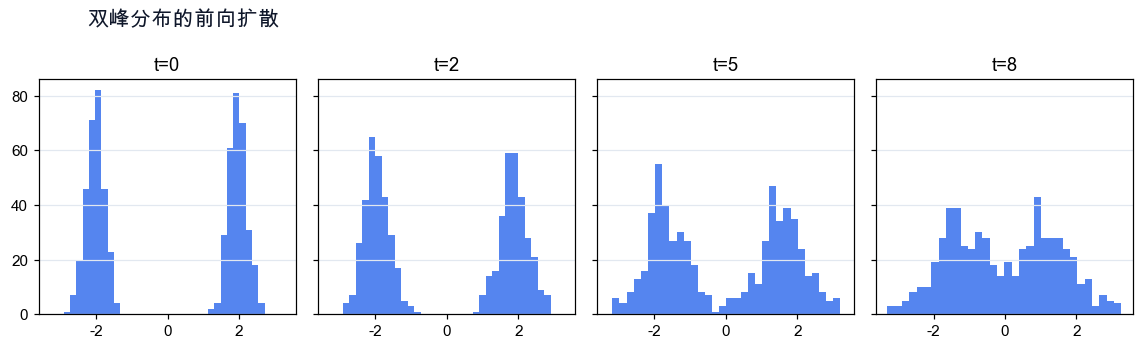

In [3]:
# 绘制不同 t 下的一维分布。
snapshots = [x0_samples, xs[1], xs[4], xs[-1]]
titles = ["t=0", "t=2", "t=5", "t=8"]
fig, axes = plt.subplots(1, 4, figsize=(10.5, 3.2), sharex=True, sharey=True)
for ax, values, title in zip(axes, snapshots, titles):
    ax.hist(values, bins=32, color="#2563eb", alpha=0.78)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
fig.suptitle("双峰分布的前向扩散", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()